# Kalman Filter (Japheth Carlson)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.arima.model import ARIMA

## Reading in the Datasets

In [29]:
# Global Temperature
def get_year(year: int):
    """
    Converts a year to an index offset from 1750.

    Args:
        year (int): A year between 1750 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1750 → 0, 1751 → 1).
    """
    return year - 1750

gt_data_filtered = np.load("datasets/gt_data_filtered.npy")


# # eg: gt_data_filtered[0, :, get_year(2015)]

# # [ (0, 1) # {0: land temperatures, 1: ocean temperatures}
# #   (0-11) # month of the year
# #   (0-266) # year 1750 - 2015
# #  ]

gt_data_noNaNs = gt_data_filtered[:, :, 100]

def get_year_noNaNs(year: int):
    """
    Converts a year to an index offset from 1850.

    Note: This is for the noNaNs data since the first 100 years have NaNs

    Args:
        year (int): A year between 1850 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1850 → 0, 1851 → 1).
    """
    return year - 1850

gt_data_land_temps = gt_data_filtered[0, :, 3:]

# # eg: gt_data_land_temps[:, get_year_land(1800)] # returns the land average temperatures for every month in the year 1800

# # [ (0-11) # month of the year
# #   (0-263) # year 1753 - 2015
# #  ]

def get_year_land(year: int):
    """
    Converts a year to an index offset from 1753.

    Note: This is for the land temps data since the first 3 years had NaNs for land

    Args:
        year (int): A year between 1753 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1753 → 0, 1754 → 1).
    """
    return year - 1753

In [30]:
# Average Temperature
avtemp_df = pd.read_csv("datasets/Average_Temperature_1900_2023.csv", index_col=0)
avtemp_df = avtemp_df.astype(float)  # Setting the temperature datatypes to floats
avtemp_df["temp"] = avtemp_df["Average_Fahrenheit_Temperature"]
avtemp_df = avtemp_df.drop(columns=["Average_Fahrenheit_Temperature"])  # Renaming the column

In [31]:
co2_ghg_df = pd.read_csv("datasets/CO2 Emissions Data.csv")
world_data = co2_ghg_df[co2_ghg_df['country'] == "World"]

# co2 emissions in the entire world (in millions of tonnes)
co2_world_df = world_data[["year", "co2"]]
# ghg emissions in the entire world (in millions of tonnes)
ghg_world_df = world_data[["year", "total_ghg"]]

co2_world_df.index = co2_world_df["year"]
co2_world_df.drop(columns=["year"], inplace=True)

co2_world_df.index = pd.RangeIndex(1750, 2025)

C:\Users\valeh\AppData\Local\Temp\ipykernel_24144\2267210959.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2_world_df.drop(columns=["year"], inplace=True)


In [32]:
# Sea Ice Levels
seaice_df = pd.read_csv("datasets/seaice.csv")
seaice_df.columns = seaice_df.columns.str.strip()  # Stripping whitespace from column names
seaice_df["date"] = pd.to_datetime(seaice_df[["Year", "Month", "Day"]])  # Making a "date" column
seaice_df = seaice_df.drop(columns=["Month", "Day", "Source Data"])
seaice_df = seaice_df.set_index("date")  # Setting the date as the index

# Computing the averages for each year
seaice_north_yearly_df = seaice_df[seaice_df["hemisphere"] == "north"].groupby("Year")["Extent"].agg(["mean", "std"])  # Computing the mean and std
seaice_north_yearly_df = seaice_north_yearly_df.drop(index=[1978, 2019])  # Don't have data for the whole of each year; changes std value

seaice_south_yearly_df = seaice_df[seaice_df["hemisphere"] == "south"].groupby("Year")["Extent"].agg(["mean", "std"])
seaice_south_yearly_df = seaice_south_yearly_df.drop(index=[1978, 2019])

# Computing daily global seaice levels
seaice_global_yearly_df = seaice_north_yearly_df + seaice_south_yearly_df

seaice_global_df = seaice_df[seaice_df["hemisphere"] == "north"]["Extent"] + seaice_df[seaice_df["hemisphere"] == "south"]["Extent"]

## First Attempt at Modeling (Local Level, America Temp. Data)

### Local Level Model

In [33]:
y = avtemp_df['temp'].copy()
model = UnobservedComponents(y, level='local level')
result = model.fit()

smoothed = result.smoothed_state[0]
filtered = result.filtered_state[0]
forecast = result.get_forecast(steps=10)

c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Local Linear Trend Model

In [34]:
y = avtemp_df['temp'].copy()
model = UnobservedComponents(y, level='local linear trend')
result = model.fit()

smoothed_level = result.smoothed_state[0]
smoothed_slope = result.smoothed_state[1]
forecast = result.get_forecast(steps=10)

c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Plot 1:  Kalman Filter Alongside All Observations

Exactly what it sounds like... a standard Kalman filter with all observations given from 1900 -- present.

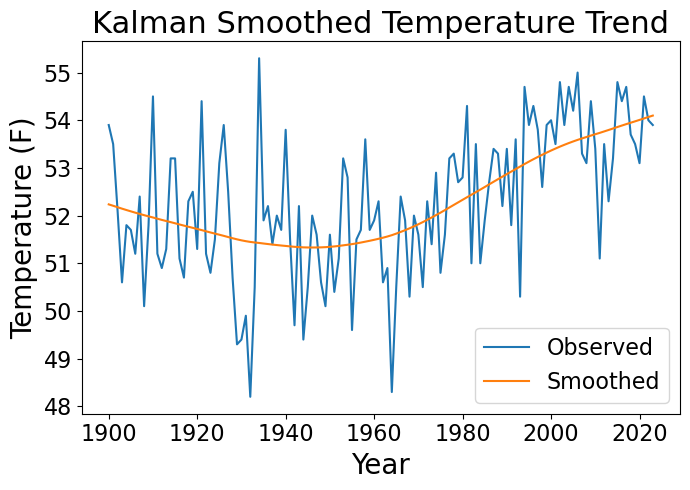

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(y.index, y.values, label='Observed')
ax.plot(y.index, smoothed_level, label='Smoothed')

ax.set_title('Kalman Smoothed Temperature Trend', fontsize=22)
ax.set_xlabel('Year', fontsize=20)
ax.set_ylabel('Temperature (F)', fontsize=20)

ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()

## Kalman Prediction 1:  Local Linear Model

Training on temperature data from 1900 -- 1999, we then forecast from 2000 -- present, comparing to actual data to validate accuracy of forecast over ~two decades.

In [36]:
# Read in temperature series and give annual index.
y = avtemp_df['temp'].copy()
y.index = pd.PeriodIndex(y.index.astype(int), freq='Y')

# Train on years 1900 - 1999, forecast from 2000 - present.
train = y.loc[:'1999']
test = y.loc['2000':]

# Build and fit Kalman filter (local linear trend).
model = UnobservedComponents(train, level='local linear trend')
res = model.fit(disp=False)

# Make forecast.
forecast = res.get_forecast(steps=len(test))
prediction = forecast.predicted_mean

# Confidence intervals... should we use these?
conf_int = forecast.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Compare forecast and observations.
rmse = np.sqrt(np.mean((prediction - test)**2))
mae = np.mean(np.abs(prediction - test))
print(f'RMSE:  {rmse}.')
print(f'MAE:  {mae}.')

RMSE:  1.0826470150516296.
MAE:  0.8552032737899568.


## Plot

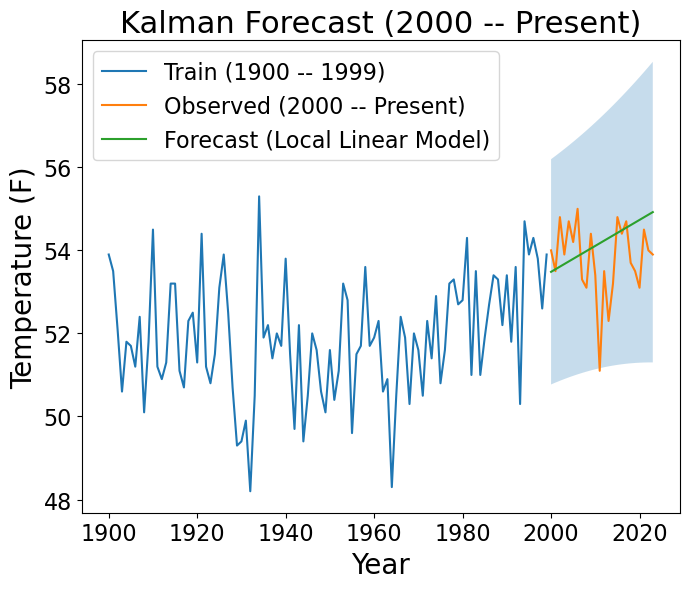

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(train.index.year, train.values, label='Train (1900 -- 1999)')
ax.plot(test.index.year, test.values, label='Observed (2000 -- Present)')
ax.plot(prediction.index.year, prediction.values, label='Forecast (Local Linear Model)')

ax.fill_between(
    prediction.index.year,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.25
)

ax.set_title('Kalman Forecast (2000 -- Present)', fontsize=22)
ax.set_xlabel('Year', fontsize=20)
ax.set_ylabel('Temperature (F)', fontsize=20)

all_years = np.arange(train.index.year.min(), prediction.index.year.max() + 1, 20)
ax.set_xticks(all_years)
ax.tick_params(axis='both', labelsize=16)
# plt.xticks(rotation=45)

ax.legend(loc='upper left', fontsize=16)

plt.tight_layout()
plt.show()

## Kalman Prediction 2:  Local Trend

Training on temperature data from 1900 -- 1999, we then forecast from 2000 -- present, comparing to actual data to validate accuracy of forecast over ~two decades.

In [38]:
# Read in temperature series and give annual index.
y = avtemp_df['temp'].copy()
y.index = pd.PeriodIndex(y.index.astype(int), freq='Y')

# Train on years 1900 - 1999, forecast from 2000 - present.
train = y.loc[:'1999']
test = y.loc['2000':]

# Build and fit Kalman filter (local linear trend).
model = UnobservedComponents(train, level='local level')
res = model.fit(disp=False)

# Make forecast.
forecast = res.get_forecast(steps=len(test))
prediction = forecast.predicted_mean

# Confidence intervals... should we use these?
conf_int = forecast.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Compare forecast and observations.
rmse = np.sqrt(np.mean((prediction - test)**2))
mae = np.mean(np.abs(prediction - test))
print(f'RMSE:  {rmse}.')
print(f'MAE:  {mae}.')

RMSE:  1.1067793381447435.
MAE:  0.9213520779954099.


## Plot

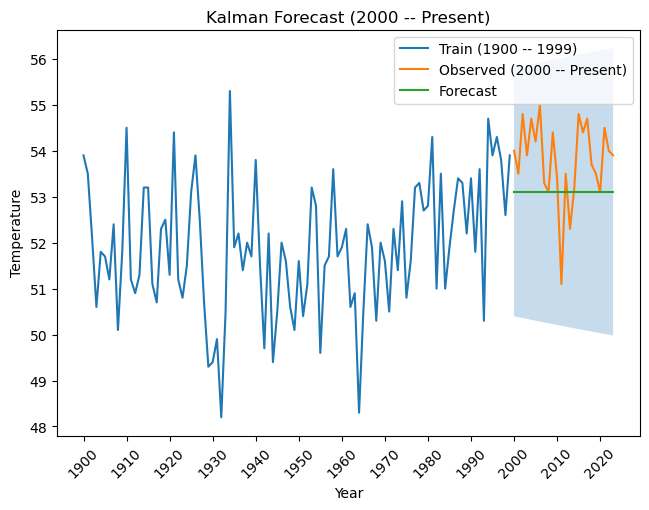

In [39]:
plt.plot(train.index.year, train.values, label='Train (1900 -- 1999)')
plt.plot(test.index.year, test.values, label='Observed (2000 -- Present)')
plt.plot(prediction.index.year, prediction.values, label='Forecast')

plt.fill_between(prediction.index.year, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.25)

plt.title('Kalman Forecast (2000 -- Present)')
plt.tight_layout()
plt.xlabel('Year')
plt.ylabel('Temperature')

all_years = np.arange(train.index.year.min(), prediction.index.year.max() + 1, 10)
plt.xticks(all_years, rotation=45)
plt.legend()

plt.show()

## Kalman Prediction 3:  Smoothing Model

Training on temperature data from 1900 -- 1999, we then forecast from 2000 -- present, comparing to actual data to validate accuracy of forecast over ~two decades.

In [40]:
# Read in temperature series and give annual index.
y = avtemp_df['temp'].copy()
y.index = pd.PeriodIndex(y.index.astype(int), freq='Y')

# Train on years 1900 - 1999, forecast from 2000 - present.
train = y.loc[:'1999']
test = y.loc['2000':]

# Build and fit Kalman filter (local linear trend).
model = UnobservedComponents(train, level='smooth trend')
res = model.fit(disp=False)

# Make forecast.
forecast = res.get_forecast(steps=len(test))
prediction = forecast.predicted_mean

# Confidence intervals... should we use these?
conf_int = forecast.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Compare forecast and observations.
rmse = np.sqrt(np.mean((prediction - test)**2))
mae = np.mean(np.abs(prediction - test))
print(f'RMSE:  {rmse}.')
print(f'MAE:  {mae}.')

RMSE:  1.0826545044533105.
MAE:  0.8552089506617874.


## Plot

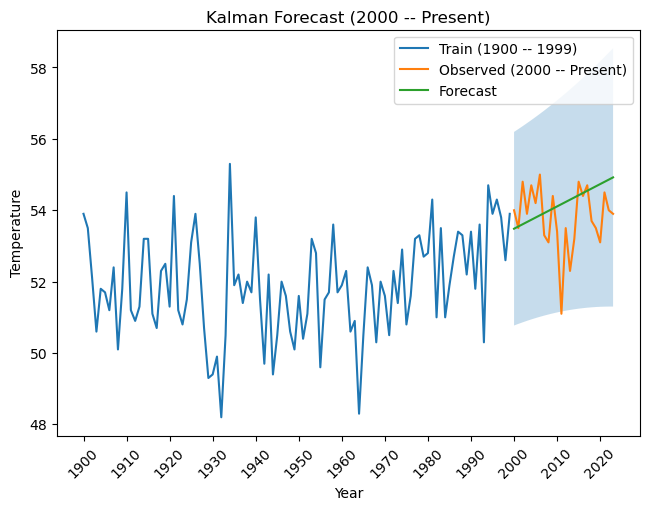

In [41]:
plt.plot(train.index.year, train.values, label='Train (1900 -- 1999)')
plt.plot(test.index.year, test.values, label='Observed (2000 -- Present)')
plt.plot(prediction.index.year, prediction.values, label='Forecast')

plt.fill_between(prediction.index.year, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.25)

plt.title('Kalman Forecast (2000 -- Present)')
plt.tight_layout()
plt.xlabel('Year')
plt.ylabel('Temperature')

all_years = np.arange(train.index.year.min(), prediction.index.year.max() + 1, 10)
plt.xticks(all_years, rotation=45)
plt.legend()

plt.show()

## ARIMA Model (Statsmodels' ARIMA class uses the Kalman filter under the hood)

The idea here is that I really wanted to see the relationship between $CO^2$ and temperature to make the forecast a bit less linear.  That's tough to do with Kalman, so I tried an ARIMA model to share with Ethan.

In [42]:
# greenhouse gases dataframe by country. Each row has the greenhouse gas emissions for a country by year
co2ghg_df = pd.read_csv("datasets/co2_ghg.csv")

world_ghg_df = co2ghg_df[co2ghg_df["Country"] == "World"].drop(columns="Country")
worldghg_numpy = world_ghg_df.to_numpy()[0]

In [43]:
temp = avtemp_df['temp'].copy()
temp.index = temp.index.astype(int)

co2 = world_ghg_df.iloc[0].copy()
co2.index = co2.index.astype(int)
co2 = co2.astype(float)

In [44]:
df = pd.concat([temp.rename('temp'), co2.rename('co2')], axis=1).dropna()

train = df.loc[1900:1999]
test = df.loc[2000:]

y_train = train['temp']
X_train = train[['co2']]

y_test = test['temp']
X_test = test[['co2']]

model = ARIMA(y_train, exog=X_train, order=(1,1,1))
result = model.fit()

forecast_result = result.get_forecast(steps=len(y_test), exog=X_test)
prediction = forecast_result.predicted_mean

# Should we use this?
ci = forecast_result.conf_int()

c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index 

### Plot

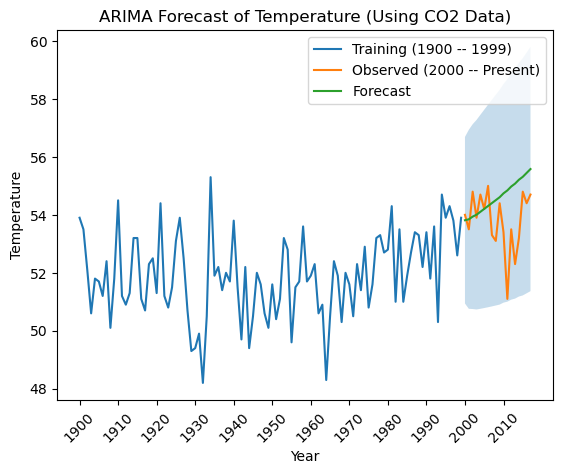

In [45]:
forecast_df = forecast_result.summary_frame()

# Without this, we have a weird indexing result.
prediction.index = y_test.index
forecast_df.index = y_test.index

plt.plot(y_train.index, y_train.values, label='Training (1900 -- 1999)')
plt.plot(y_test.index, y_test.values, label='Observed (2000 -- Present)')
plt.plot(prediction.index, prediction.values, label='Forecast')

plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], alpha=0.25)

plt.xlabel('Year')
plt.ylabel('Temperature')
plt.title('ARIMA Forecast of Temperature (Using CO2 Data)')

all_years = np.arange(y_train.index.min(), prediction.index.max() + 1, 10)
plt.xticks(all_years, rotation=45)
plt.legend()

plt.show()

## Scenario:  Targeted CO2 Reduction Over 10 Years

What if we were to reduce carbon emissions by 3% each year?  When would we actually see a decline in temperature?

In [46]:
# Refit over full data.
y_full = df['temp']
X_full = df[['co2']]

full_model = ARIMA(y_full, exog=X_full, order=(1, 1, 1))
full_result = full_model.fit()

last_year = int(df.index[-1])
num_years_predict = 50
future_years = np.arange(last_year + 1, last_year + 1 + num_years_predict)

last_co2 = df['co2'].iloc[-1]
rate_of_reduct = 0.03

future_co2 = pd.DataFrame({
    'co2': [last_co2 * (1 - rate_of_reduct)**k for k in range(1, 1 + num_years_predict)]
}, index=future_years)

hypoth_forecast = result.get_forecast(steps=num_years_predict, exog=future_co2)
hypoth_df = hypoth_forecast.summary_frame()
hypoth_mean = hypoth_df['mean']
hypoth_conf_int = hypoth_df[['mean_ci_lower', 'mean_ci_upper']]

c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\valeh\Documents\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index 

### Plot

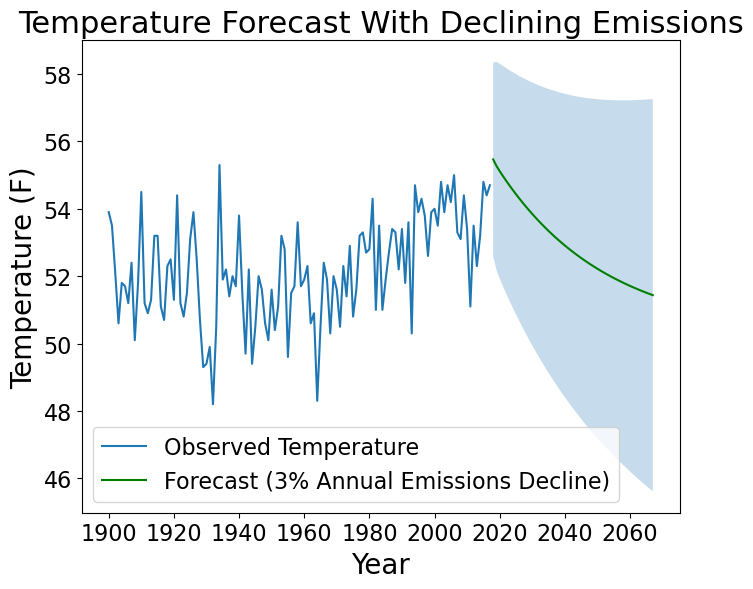

In [56]:
fig, ax = plt.subplots(figsize=(7, 6))

# Align all forecasts to start at same year.
hypoth_mean.index = future_years
hypoth_df.index = future_years

ax.plot(df.index, df['temp'].values, label='Observed Temperature')
ax.plot(
    hypoth_mean.index,
    hypoth_mean.values,
    label='Forecast (3% Annual Emissions Decline)',
    color='green'
)

ax.fill_between(
    hypoth_df.index,
    hypoth_df['mean_ci_lower'],
    hypoth_df['mean_ci_upper'],
    alpha=0.25
)

ax.set_title('Temperature Forecast With Declining Emissions', fontsize=22)
ax.set_xlabel('Year', fontsize=20)
ax.set_ylabel('Temperature (F)', fontsize=20)

all_years = np.arange(y_train.index.min(), prediction.index.max() + 1 + num_years_predict + 5, 20)
ax.set_xticks(all_years)
ax.tick_params(axis='both', labelsize=16)
ax.tick_params(axis='x')

ax.legend(fontsize=16, loc='lower left')

plt.tight_layout()
plt.show()